### Import libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

In [2]:
import numpy as np

### Extract data from folders

In [3]:
train_dataset_path = "pneumonia_detection/train"

train_img_path = []
train_labels = []

class_names = ["NORMAL", "PNEUMONIA"]

for label, class_name in enumerate(class_names):
  class_dir = os.path.join(train_dataset_path, class_name)

  for file in os.listdir(class_dir):
    train_img_path.append(os.path.join(class_dir, file))
    train_labels.append(label)

In [4]:
val_dataset_path = "pneumonia_detection/val"

val_img_path = []
val_labels = []

class_names = ["NORMAL", "PNEUMONIA"]

for label, class_name in enumerate(class_names):
  class_dir = os.path.join(val_dataset_path, class_name)

  for file in os.listdir(class_dir):
    val_img_path.append(os.path.join(class_dir, file))
    val_labels.append(label)

In [5]:
test_dataset_path = "pneumonia_detection/test"

test_img_path = []
test_labels = []

class_names = ["NORMAL", "PNEUMONIA"]

for label, class_name in enumerate(class_names):
  class_dir = os.path.join(test_dataset_path, class_name)

  for file in os.listdir(class_dir):
    test_img_path.append(os.path.join(class_dir, file))
    test_labels.append(label)

### Analyse the train data - class imbalance, etc

In [6]:
count = np.bincount(train_labels)
print(f"Class distribution in training data:")
for label, class_count in enumerate(count):
  print(f"Class {class_names[label]}: {class_count}")

count = np.bincount(val_labels)
print(f"Class distribution in validation data:")
for label, class_count in enumerate(count):
  print(f"Class {class_names[label]}: {class_count}")

count = np.bincount(test_labels)
print(f"Class distribution in test data:")
for label, class_count in enumerate(count):
  print(f"Class {class_names[label]}: {class_count}")

Class distribution in training data:
Class NORMAL: 1236
Class PNEUMONIA: 3770
Class distribution in validation data:
Class NORMAL: 113
Class PNEUMONIA: 113
Class distribution in test data:
Class NORMAL: 234
Class PNEUMONIA: 390


Based on the output obtained, use the formula n1w1 = n2w2 to assign weights to each class. Initially assume weight for pneumonia class as 1 and calculate n1 (weight for normal class) using the formula w1 = n2/n1 where n2 is number of pneumonia samples in training data and n1 is number of normal samples in training data. Based on this calculation, I have assigned the class weights as follows -> w1 = 3; w2 = 1

In [7]:
class_weight = {
    0: 3.0,
    1: 1.0
}

### Creating dataset pipeline for train, test and validation datasets

In [8]:
train_data = tf.data.Dataset.from_tensor_slices((train_img_path, train_labels))
val_data = tf.data.Dataset.from_tensor_slices((val_img_path,val_labels))
test_data = tf.data.Dataset.from_tensor_slices((test_img_path, test_labels))

In [9]:
def preprocessing(path, label):
  image = tf.io.read_file(path)
  image = tf.image.decode_jpeg(image, channels=3)
  image = tf.image.resize(image, ((224,224)))
  image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
  return image, label


In [10]:
train_data = train_data.map(preprocessing, num_parallel_calls=tf.data.AUTOTUNE)
train_data = train_data.shuffle(len(train_labels))
train_data = train_data.batch(32)
train_data = train_data.prefetch(tf.data.AUTOTUNE)

val_data = val_data.map(preprocessing, num_parallel_calls=tf.data.AUTOTUNE)
val_data = val_data.batch(32)
val_data = val_data.prefetch(tf.data.AUTOTUNE)

test_data = test_data.map(preprocessing, num_parallel_calls=tf.data.AUTOTUNE)
test_data = test_data.batch(32)
test_data = test_data.prefetch(tf.data.AUTOTUNE)

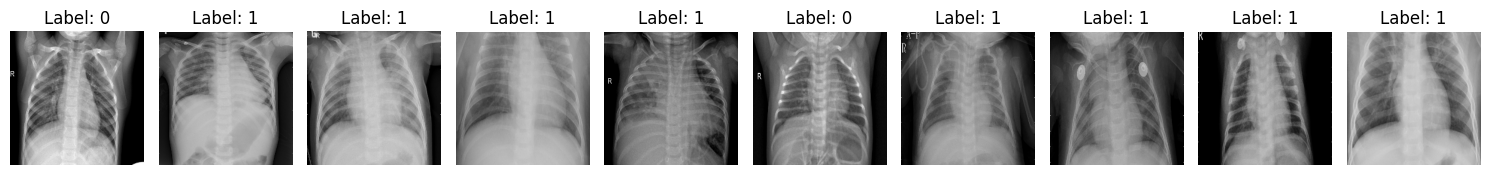

In [11]:
for images, labels in train_data.take(1):
  plt.figure(figsize=(15, 10))
  for i in range(10):
    display_image = (images[i] + 1)/2
    plt.subplot(1, 10, i + 1)
    plt.imshow(display_image)
    plt.title(f"Label: {labels[i].numpy()}")
    plt.axis('off')
  plt.tight_layout()
  plt.show()

### Building the classification model

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, GlobalAveragePooling2D, MaxPooling2D, Dropout, Dense

model = Sequential([
    Conv2D(32, (3,3),padding="same", activation="relu", input_shape = (224,224,3)),
    MaxPooling2D(),
    Conv2D(64, (3,3), padding="same", activation="relu"),
    MaxPooling2D(),
    Conv2D(128,(3,3), padding="same", activation="relu"),
    MaxPooling2D(),
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall(),
        tf.keras.metrics.AUC(name='roc_auc'),
        tf.keras.metrics.AUC(curve='PR', name='pr_auc')
    ]
)

In [15]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.05,
    patience = 3,
    restore_best_weights=True
)

In [16]:
history = model.fit(
    train_data,
    validation_data = val_data,
    epochs = 20,
    callbacks = early_stopping,
    class_weight = class_weight
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 335ms/step - accuracy: 0.5525 - loss: 0.9291 - pr_auc: 0.8801 - precision: 0.8848 - recall: 0.4666 - roc_auc: 0.7160 - val_accuracy: 0.8584 - val_loss: 0.4208 - val_pr_auc: 0.9489 - val_precision: 0.9880 - val_recall: 0.7257 - val_roc_auc: 0.9294
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 345ms/step - accuracy: 0.8606 - loss: 0.4997 - pr_auc: 0.9746 - precision: 0.9632 - recall: 0.8472 - roc_auc: 0.9277 - val_accuracy: 0.8761 - val_loss: 0.3726 - val_pr_auc: 0.9499 - val_precision: 0.9670 - val_recall: 0.7788 - val_roc_auc: 0.9351
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 364ms/step - accuracy: 0.8869 - loss: 0.4071 - pr_auc: 0.9830 - precision: 0.9751 - recall: 0.8721 - roc_auc: 0.9493 - val_accuracy: 0.8982 - val_loss: 0.2929 - val_pr_auc: 0.9424 - val_precision: 0.9091 - val_recall: 0.8850 - val_roc_auc: 0.9359
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 69s 417ms/step - accuracy: 0.9017 - loss: 0.3740 - pr_auc: 0.9848 - precision: 0.9756 -

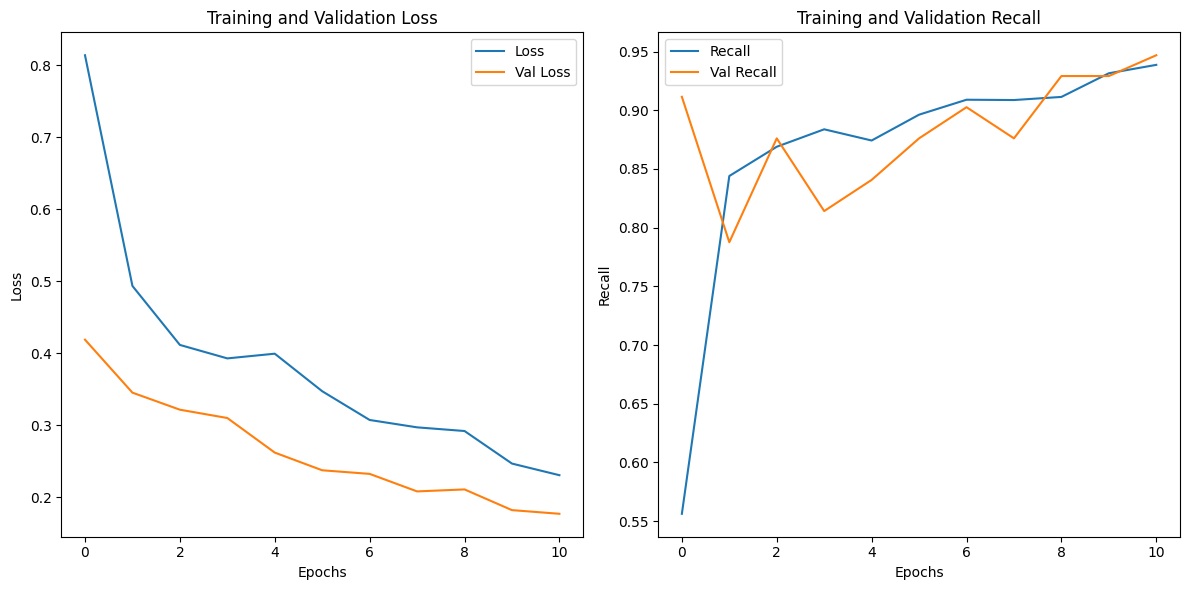

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) # Subplot for Loss
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["Loss", "Val Loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.subplot(1, 2, 2) # Subplot for Recall
plt.plot(history.history["recall"])
plt.plot(history.history["val_recall"])
plt.legend(["Recall", "Val Recall"])
plt.xlabel("Epochs")
plt.ylabel("Recall")
plt.title("Training and Validation Recall")

plt.tight_layout()
plt.show()

### Evaluating the model on the test set

In [19]:
results = model.evaluate(test_data, return_dict = True)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 346ms/step - accuracy: 0.8526 - loss: 0.3913 - pr_auc: 0.9448 - precision: 0.8371 - recall: 0.9487 - roc_auc: 0.9210


In [20]:
results

{'accuracy': 0.8525640964508057,
 'loss': 0.3912961483001709,
 'pr_auc': 0.944770336151123,
 'precision': 0.837104082107544,
 'recall': 0.9487179517745972,
 'roc_auc': 0.9209784865379333}

In [21]:
print(f"Results")
print(f"Loss:{results["loss"]:.2f}")
print(f"Accuracy:{results["accuracy"]:.2f}")
print(f"Precision:{results["precision"]:.2f}")
print(f"Recall:{results["recall"]:.2f}")
print(f"AUC-ROC:{results["roc_auc"]:.2f}")
print(f"PR-AUC:{results["pr_auc"]:.2f}")

Results
Loss:0.39
Accuracy:0.85
Precision:0.84
Recall:0.95
AUC-ROC:0.92
PR-AUC:0.94


### Confusion matrix

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

y_preds = model.predict(test_data)

y_preds = (y_preds > 0.5).astype(int).flatten()

# for y_true

y_true = []

for image,label in test_data:
  y_true.extend(label.numpy())

y_true = np.array(y_true)

# Confusion matrix

cm = confusion_matrix(y_true, y_preds)
print(cm)

# Classification report

print(classification_report(y_true, y_preds))

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 360ms/step
[[162  72]
 [ 20 370]]
              precision    recall  f1-score   support

           0       0.89      0.69      0.78       234
           1       0.84      0.95      0.89       390

    accuracy                           0.85       624
   macro avg       0.86      0.82      0.83       624
weighted avg       0.86      0.85      0.85       624



In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

display = ConfusionMatrixDisplay.from_predictions(cm, display_labels=["NORMAL", "PNEUMONIA"])

display.plot()

TypeError: ConfusionMatrixDisplay.from_predictions() missing 1 required positional argument: 'y_pred'